In [1]:
import pandas as pd

df = pd.read_csv('./data/cleaned_data/completions.csv')
display(df.head())

,Timestamp,Unique ID,What is your Voyage?,Completed Voyage?,Completion Status,Certificate Issue Date,What is your Tier?,"What is the name of the project? (If there isn't a name you can just write ""no name"")","What tech-stack did you use for your project? (ex. React, webpack, node.js, MongoDB, etc.)","On a scale of 0-10, how likely are you to recommend Chingu to a friend or colleagues?",Status (from Voyage Signups Link),Role (from Voyage Signups Link),Product
0,2025-02-23 08:51:00,b2e0990e9fa5377695dbfb36cc170649,V53,No,Incomplete Agile Leaders Course,NaN,Tier 3,Meal Planner,"React, TypeScript, Material UI, Emotion, Tailw...",10.0,Active,Scrum Master,Unknown
1,2025-02-23 08:51:00,4ab0dddf11a4b0f4a2b912d60a8470d5,V53,Yes,Completed,NaN,Tier 3,Meal Planner,"React, TypeScript, Material UI, Emotion, Tailw...",10.0,Inactive,Developer,Unknown
2,2025-02-23 08:51:00,6168fe00dc59a2d9acc000f5f0b6ce41,V53,Yes,Cert Issued,2025-02-23,Tier 3,Meal Planner,"React, TypeScript, Material UI, Emotion, Tailw...",10.0,Active,Voyage Guide,Unknown
3,2025-02-23 08:51:00,47b0214b643ac04278dc1fb476d22920,V53,Yes,Completed,NaN,Tier 3,Meal Planner,"React, TypeScript, Material UI, Emotion, Tailw...",10.0,Active,Developer,Unknown
4,2025-02-23 08:51:00,e713f2d8b2c98ecd4713466507cdbd8e,V53,No,Dropped,NaN,Tier 3,Meal Planner,"React, TypeScript, Material UI, Emotion, Tailw...",10.0,Dropped,Developer,Unknown


In [2]:
# Examine the shape of the DataFrame
print("DataFrame Shape:", df.shape)

# Check the data types of each column
print("\nData Types:\n", df.dtypes)

# Calculate descriptive statistics for numerical columns
print("\nDescriptive Statistics:\n", df.describe())

# Identify missing values
print("\nMissing Values:\n", df.isnull().sum())

# Explore the unique values for categorical columns
for column in df.select_dtypes(include=['object']).columns:
  print(f"\nUnique values for {column}:\n", df[column].unique()[:10])  # Print only the first 10 unique values to avoid excessive output
  print(f"\nValue counts for {column}:\n", df[column].value_counts()[:10])  # Print only the first 10 value counts to avoid excessive output


DataFrame Shape: (2970, 13)

Data Types:
 Timestamp                                                                                      object
Unique ID                                                                                      object
What is your Voyage?                                                                           object
Completed Voyage?                                                                              object
Completion Status                                                                              object
Certificate Issue Date                                                                         object
What is your Tier?                                                                             object
What is the name of the project? (If there isn't a name you can just write "no name")          object
What tech-stack did you use for your project? (ex. React, webpack, node.js, MongoDB, etc.)     object
On a scale of 0-10, how likely are you t

In [3]:
# Investigate missing values in more detail
for column in df.columns:
  if df[column].isnull().any():
    print(f"\nMissing values in {column}:")
    print(df[df[column].isnull()][['Timestamp', 'Unique ID', 'What is your Voyage?', 'Completed Voyage?', 'Completion Status', column]].head(10))


Missing values in Timestamp:
     Timestamp                         Unique ID What is your Voyage?  \
961        NaN  a1b24e7ff67269c2e9f2ffe0b2bce687                  V47   
1459       NaN  52137efeda8ff9eef203062ed3c6c1a6                  V45   
1460       NaN  0253d24ef8bc837331a1d8184fc0314c                  V46   
1498       NaN  fae3739c5da418331c2e7e303a80b53a                  V99   
1974       NaN  cc8c4ed1f3e685dad36b43c3b2a49260                  V47   
2171       NaN  c9476fc1069d3ebbf36d8b237c156e32                  V41   
2172       NaN  ff06849a14c04e8ca92adec20d161fe6                  V41   
2173       NaN  0a8fabc99fa8fedbfeaf21c247210903                  V41   
2174       NaN  e7592dad013a476ebe520107ddf071cf                  V41   
2175       NaN  2eea25790a273bde8a87a58c7ad7ba0d                  V41   

     Completed Voyage?      Completion Status Timestamp  
961                Yes            Cert Issued       NaN  
1459                No  No Project Submission     

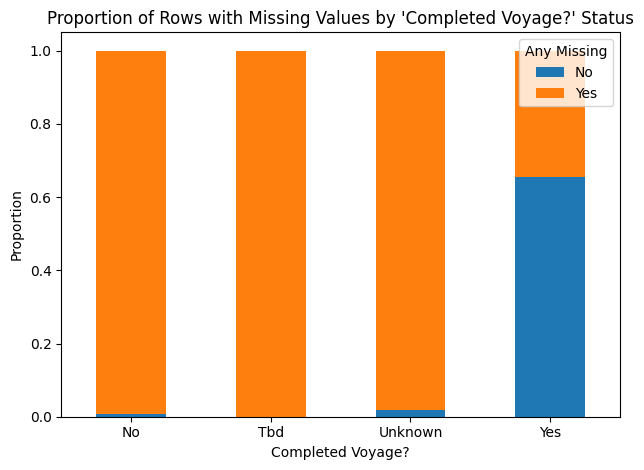

In [6]:
import matplotlib.pyplot as plt
# Create a copy of the dataframe with a column to indicate if a row has any missing value
df_missing_analysis = df.copy()
df_missing_analysis['Any Missing'] = df_missing_analysis.isnull().any(axis=1)

# Group by 'Completed Voyage?' and check the proportion of rows with missing data
missing_by_completion = df_missing_analysis.groupby('Completed Voyage?')['Any Missing'].value_counts(normalize=True).unstack()

# Plot the results
missing_by_completion.plot(kind='bar', stacked=True)
plt.title("Proportion of Rows with Missing Values by 'Completed Voyage?' Status")
plt.ylabel("Proportion")
plt.xlabel("Completed Voyage?")
plt.legend(title='Any Missing', labels=['No', 'Yes'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

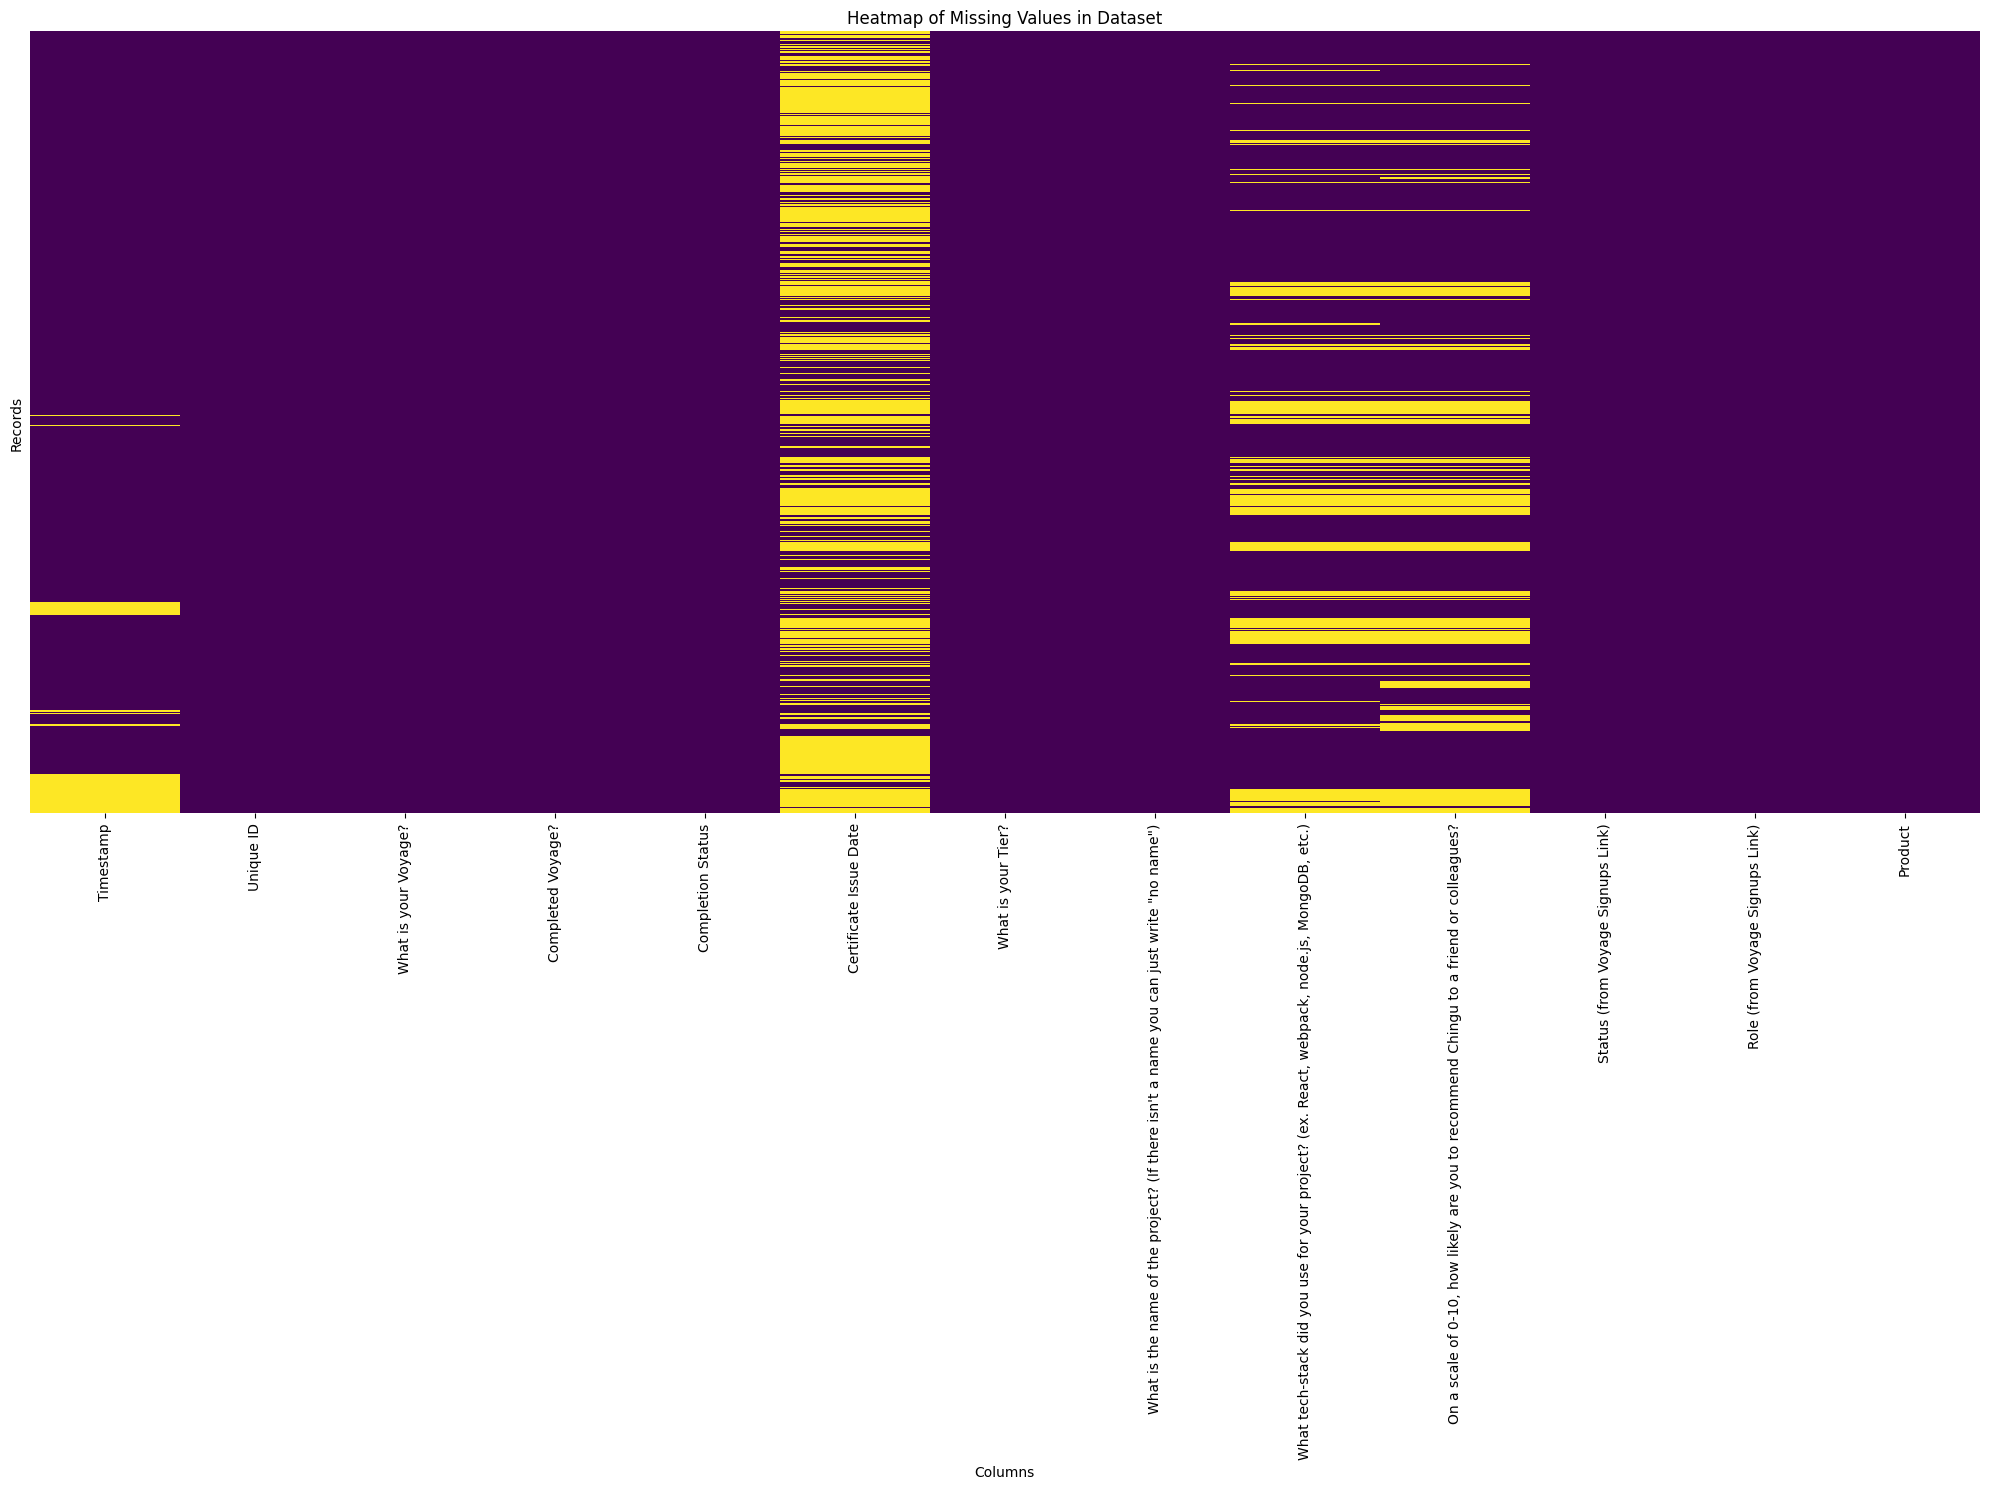

In [12]:
import warnings 
warnings.filterwarnings('ignore')
import seaborn as sns
# Create a heatmap to visualize the pattern of missing data across the dataset
plt.figure(figsize=(20, 15))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Heatmap of Missing Values in Dataset")
plt.xlabel("Columns")
plt.ylabel("Records")
plt.tight_layout()
plt.show()


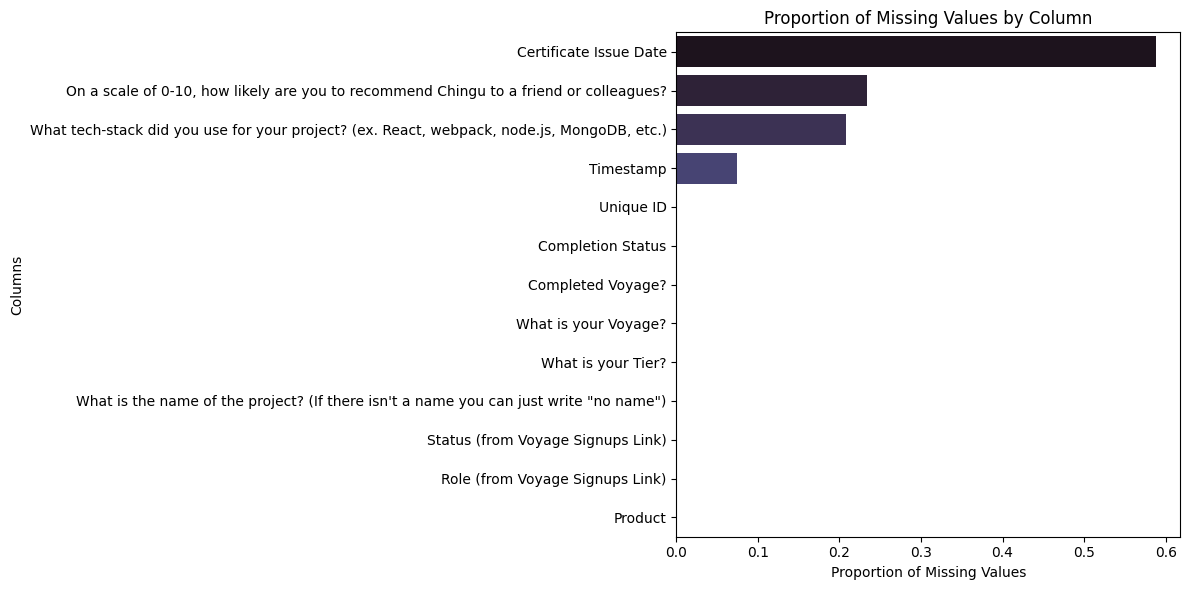

In [13]:

# Calculate the proportion of missing values in each column
missing_proportions = df.isnull().mean().sort_values(ascending=False)

# Plot the proportions as a bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_proportions.values, y=missing_proportions.index, palette="mako")
plt.xlabel("Proportion of Missing Values")
plt.ylabel("Columns")
plt.title("Proportion of Missing Values by Column")
plt.tight_layout()
plt.show()


In [15]:
# Copy the original DataFrame to avoid modifying it directly
df_cleaned = df.copy()

# Convert 'Timestamp' and 'Certificate Issue Date' to datetime objects if possible
for column in ['Timestamp', 'Certificate Issue Date']:
  try:
    df_cleaned[column] = pd.to_datetime(df_cleaned[column])
  except ValueError:
    print(f"Could not convert {column} to datetime.")

# Handle missing values in numerical columns by imputing with the mean
for col in df_cleaned.select_dtypes(include=['number']).columns:
    if df_cleaned[col].isnull().any():
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mean())

# Handle missing values in categorical columns by creating a new category for missing values
for col in df_cleaned.select_dtypes(include=['object']).columns:
    if df_cleaned[col].isnull().any():
        df_cleaned[col] = df_cleaned[col].fillna('Missing')

# Remove duplicate rows
df_cleaned.drop_duplicates(inplace=True)

# Display the first few rows of the cleaned DataFrame
display(df_cleaned.head())

,Timestamp,Unique ID,What is your Voyage?,Completed Voyage?,Completion Status,Certificate Issue Date,What is your Tier?,"What is the name of the project? (If there isn't a name you can just write ""no name"")","What tech-stack did you use for your project? (ex. React, webpack, node.js, MongoDB, etc.)","On a scale of 0-10, how likely are you to recommend Chingu to a friend or colleagues?",Status (from Voyage Signups Link),Role (from Voyage Signups Link),Product
0,2025-02-23 08:51:00,b2e0990e9fa5377695dbfb36cc170649,V53,No,Incomplete Agile Leaders Course,NaT,Tier 3,Meal Planner,"React, TypeScript, Material UI, Emotion, Tailw...",10.0,Active,Scrum Master,Unknown
1,2025-02-23 08:51:00,4ab0dddf11a4b0f4a2b912d60a8470d5,V53,Yes,Completed,NaT,Tier 3,Meal Planner,"React, TypeScript, Material UI, Emotion, Tailw...",10.0,Inactive,Developer,Unknown
2,2025-02-23 08:51:00,6168fe00dc59a2d9acc000f5f0b6ce41,V53,Yes,Cert Issued,2025-02-23,Tier 3,Meal Planner,"React, TypeScript, Material UI, Emotion, Tailw...",10.0,Active,Voyage Guide,Unknown
3,2025-02-23 08:51:00,47b0214b643ac04278dc1fb476d22920,V53,Yes,Completed,NaT,Tier 3,Meal Planner,"React, TypeScript, Material UI, Emotion, Tailw...",10.0,Active,Developer,Unknown
4,2025-02-23 08:51:00,e713f2d8b2c98ecd4713466507cdbd8e,V53,No,Dropped,NaT,Tier 3,Meal Planner,"React, TypeScript, Material UI, Emotion, Tailw...",10.0,Dropped,Developer,Unknown


In [16]:
# Descriptive statistics for numerical variables
numerical_stats = df_cleaned.describe()
display(numerical_stats)

# Descriptive statistics for categorical variables
categorical_stats = df_cleaned.describe(include=['object'])
display(categorical_stats)

# Correlation matrix (Pearson correlation) for numerical variables
correlation_matrix = df_cleaned.select_dtypes(include=['number']).corr(method='pearson')
display(correlation_matrix)

# Analyze the distribution of user feedback scores across different project types
feedback_by_project = df_cleaned.groupby('What is the name of the project? (If there isn\'t a name you can just write "no name")')['On a scale of 0-10, how likely are you to recommend Chingu to a friend or colleagues?'].mean()
display(feedback_by_project)

# Analyze the distribution of completion status across different tech stacks
completion_by_tech = df_cleaned.groupby('What tech-stack did you use for your project? (ex. React, webpack, node.js, MongoDB, etc.)')['Completed Voyage?'].value_counts(normalize=True)
display(completion_by_tech)

,Timestamp,Certificate Issue Date,"On a scale of 0-10, how likely are you to recommend Chingu to a friend or colleagues?"
count,2744,1223,2965.000000
mean,2023-07-16 22:05:39.008746240,2023-06-20 00:50:37.775960832,9.260649
min,2019-11-10 12:55:00,2021-07-19 00:00:00,2.000000
25%,2023-02-12 09:45:00,2022-11-20 00:00:00,9.000000
50%,2023-09-14 14:25:00,2023-06-11 00:00:00,10.000000
75%,2024-04-17 08:11:00,2023-11-19 00:00:00,10.000000
max,2025-02-23 08:51:00,2025-02-23 00:00:00,10.000000
std,NaN,NaN,1.131355


,Unique ID,What is your Voyage?,Completed Voyage?,Completion Status,What is your Tier?,"What is the name of the project? (If there isn't a name you can just write ""no name"")","What tech-stack did you use for your project? (ex. React, webpack, node.js, MongoDB, etc.)",Status (from Voyage Signups Link),Role (from Voyage Signups Link),Product
count,2965,2965,2965,2965,2965,2965,2965,2965,2965,2965
unique,1905,44,4,45,16,465,446,11,18,6
top,2c0dcccb7bb36e6c724b073acf755fc9,V45,Yes,Completed,Tier 3,Nan,Missing,Active,Developer,Unknown
freq,14,278,1604,814,772,598,615,1960,2245,2681


,"On a scale of 0-10, how likely are you to recommend Chingu to a friend or colleagues?"
"On a scale of 0-10, how likely are you to recommend Chingu to a friend or colleagues?",1.0


What is the name of the project? (If there isn't a name you can just write "no name")
15                                 9.261309
21St Century Meteorite Strikes    10.000000
3                                  9.261309
4Foodies                          10.000000
Abracadabra                       10.000000
                                    ...    
Zenith                             5.000000
Zero-Waste Recipes                10.000000
Zest                              10.000000
Zodaily                            9.445982
[Note](Me)                        10.000000
Name: On a scale of 0-10, how likely are you to recommend Chingu to a friend or colleagues?, Length: 465, dtype: float64

What tech-stack did you use for your project? (ex. React, webpack, node.js, MongoDB, etc.)                                                                         Completed Voyage?
   - Backend: MongoDB, Express/Node.js    - Frontend: Javascript, React, HTML/CSS                                                                                  Unknown              1.000000
 MERN - web client implemented with react and redux, consumes data from rest api build with express, data is persisted in mongo database. Package manager is npm.  Unknown              1.000000
 React, React Router, D3                                                                                                                                           Unknown              1.000000
(Client) React, MaterialUI, (Server) NodeJS/Express, GraphQL, DataLoader, Mongoose/MongoDB                                                                         Unknown              1.000000
(Frontend) React, NextJS, Apollo Client, TypeSc

In [18]:
# Analyze completion rates by project type
completion_by_project = df_cleaned.groupby('What is the name of the project? (If there isn\'t a name you can just write "no name")')['Completed Voyage?'].value_counts(normalize=True)
display(completion_by_project)

# Analyze completion rates by tech stack
completion_by_tech = df_cleaned.groupby('What tech-stack did you use for your project? (ex. React, webpack, node.js, MongoDB, etc.)')['Completed Voyage?'].value_counts(normalize=True)
display(completion_by_tech)

What is the name of the project? (If there isn't a name you can just write "no name")  Completed Voyage?
15                                                                                     Unknown              1.00
21St Century Meteorite Strikes                                                         Yes                  0.60
                                                                                       No                   0.40
3                                                                                      Unknown              1.00
4Foodies                                                                               Yes                  0.60
                                                                                                            ... 
Zest                                                                                   Yes                  1.00
Zodaily                                                                                Yes              

What tech-stack did you use for your project? (ex. React, webpack, node.js, MongoDB, etc.)                                                                         Completed Voyage?
   - Backend: MongoDB, Express/Node.js    - Frontend: Javascript, React, HTML/CSS                                                                                  Unknown              1.000000
 MERN - web client implemented with react and redux, consumes data from rest api build with express, data is persisted in mongo database. Package manager is npm.  Unknown              1.000000
 React, React Router, D3                                                                                                                                           Unknown              1.000000
(Client) React, MaterialUI, (Server) NodeJS/Express, GraphQL, DataLoader, Mongoose/MongoDB                                                                         Unknown              1.000000
(Frontend) React, NextJS, Apollo Client, TypeSc

In [19]:
# Analyze completion rates by project type
completion_by_project = df_cleaned.groupby('What is the name of the project? (If there isn\'t a name you can just write "no name")')['Completed Voyage?'].value_counts(normalize=True)
project_completion_rates = completion_by_project.unstack()
display(project_completion_rates)

# Analyze completion rates by tech stack (if possible)
completion_by_tech = df_cleaned.groupby('What tech-stack did you use for your project? (ex. React, webpack, node.js, MongoDB, etc.)')['Completed Voyage?'].value_counts(normalize=True)
tech_completion_rates = completion_by_tech.unstack()
display(tech_completion_rates)

# You can sort the tables to identify these patterns more easily.


Completed Voyage?,No,Tbd,Unknown,Yes
"What is the name of the project? (If there isn't a name you can just write ""no name"")",,,,
15,NaN,NaN,1.0,NaN
21St Century Meteorite Strikes,0.400000,NaN,NaN,0.600000
3,NaN,NaN,1.0,NaN
4Foodies,0.400000,NaN,NaN,0.600000
Abracadabra,0.166667,NaN,NaN,0.833333
...,...,...,...,...
Zenith,0.500000,NaN,NaN,0.500000
Zero-Waste Recipes,NaN,NaN,NaN,1.000000
Zest,NaN,NaN,NaN,1.000000


Completed Voyage?,No,Tbd,Unknown,Yes
"What tech-stack did you use for your project? (ex. React, webpack, node.js, MongoDB, etc.)",,,,
"- Backend: MongoDB, Express/Node.js - Frontend: Javascript, React, HTML/CSS",NaN,NaN,1.0,NaN
"MERN - web client implemented with react and redux, consumes data from rest api build with express, data is persisted in mongo database. Package manager is npm.",NaN,NaN,1.0,NaN
"React, React Router, D3",NaN,NaN,1.0,NaN
"(Client) React, MaterialUI, (Server) NodeJS/Express, GraphQL, DataLoader, Mongoose/MongoDB",NaN,NaN,1.0,NaN
"(Frontend) React, NextJS, Apollo Client, TypeScript ... (Backend) Express, Apollo Server, GraphQL, MongoDB with Mongoose, Redis",NaN,NaN,1.0,NaN
...,...,...,...,...
"react, three-fiber, three-drei, threatre js, framer motion, zustand, vite, leva, r3f-perf, vite.",0.333333,NaN,NaN,0.666667
"ruby on rails , postgresql, tailwind",NaN,NaN,NaN,1.000000
"t3 stack (NextTs, React, TailwindCSS, TRPC, Prisma (MySQL)). Production providers are Vercel and PlanetScale.",0.285714,NaN,NaN,0.714286


In [20]:
# Identify potential anomalies or patterns in project and tech stack completion rates

# Filter for projects with unusually high or low 'Yes' completion rates
high_completion_projects = project_completion_rates[project_completion_rates['Yes'] >= 0.9]
low_completion_projects = project_completion_rates[project_completion_rates['Yes'] <= 0.1]

# Filter for tech stacks with unusually high or low 'Yes' completion rates
high_completion_tech = tech_completion_rates[tech_completion_rates['Yes'] >= 0.9]
low_completion_tech = tech_completion_rates[tech_completion_rates['Yes'] <= 0.1]

# Combine the findings into a single DataFrame for each
anomalies_projects = pd.concat([high_completion_projects, low_completion_projects])
anomalies_tech = pd.concat([high_completion_tech, low_completion_tech])

In [21]:
anomalies_projects.head()

Completed Voyage?,No,Tbd,Unknown,Yes
"What is the name of the project? (If there isn't a name you can just write ""no name"")",,,,
Acareer,NaN,NaN,NaN,1.0
Ama,NaN,NaN,NaN,1.0
Artguessr,NaN,NaN,NaN,1.0
Booktown,NaN,NaN,NaN,1.0
Booky List,NaN,NaN,NaN,1.0


In [22]:
anomalies_tech.head()

Completed Voyage?,No,Tbd,Unknown,Yes
"What tech-stack did you use for your project? (ex. React, webpack, node.js, MongoDB, etc.)",,,,
-,NaN,NaN,NaN,1.0
Babel Webpack React-DOM React Google Maps React-Router-Dom React Hook Form React Datepicker react-use-measure Tailwind Css Headless UI React Icons Prop Types React PDF Daisy UI ESLint Axios React Vite uuid,NaN,NaN,NaN,1.0
Bootstrap 5,NaN,NaN,NaN,1.0
Bootstrap 5.0,NaN,NaN,NaN,1.0
"D3.js, Bootstrap, Netlify",NaN,NaN,NaN,1.0


In [24]:
# Sort the project completion rates table by 'Yes' completion rate
sorted_project_completion = project_completion_rates.sort_values(by='Yes', ascending=False)

# Sort the tech stack completion rates table by 'Yes' completion rate
sorted_tech_completion = tech_completion_rates.sort_values(by='Yes', ascending=False)


In [25]:
sorted_project_completion.head()

Completed Voyage?,No,Tbd,Unknown,Yes
"What is the name of the project? (If there isn't a name you can just write ""no name"")",,,,
Zest,NaN,NaN,NaN,1.0
Zero-Waste Recipes,NaN,NaN,NaN,1.0
Yumspot,NaN,NaN,NaN,1.0
Your Personality - I Or E?,NaN,NaN,NaN,1.0
Acareer,NaN,NaN,NaN,1.0


In [26]:
sorted_tech_completion.head()

Completed Voyage?,No,Tbd,Unknown,Yes
"What tech-stack did you use for your project? (ex. React, webpack, node.js, MongoDB, etc.)",,,,
"TypeScript, PostgreSQL, Sequelize, NodeJS, React, Redux, Express, Material-UI, Vite",NaN,NaN,NaN,1.0
Vanilla HTML CSS and JS,NaN,NaN,NaN,1.0
"Vanilla JS, HTML5, CSS3",NaN,NaN,NaN,1.0
"ReactJs, TypeScript, JavaScript, Node.Js, PostgreSQL, ExpressJs",NaN,NaN,NaN,1.0
"React.js, Sass, Remote Jobs Api, Axio, Framer Motion, HTML / CSS / JavaScript",NaN,NaN,NaN,1.0


In [27]:
# Sort the project completion rates table to identify patterns
sorted_project_completion_rates = project_completion_rates.sort_values(by=['Yes'], ascending=False)
display(sorted_project_completion_rates)

# You can also explore other sorting criteria, such as the 'No' column, to identify projects with low completion rates.

Completed Voyage?,No,Tbd,Unknown,Yes
"What is the name of the project? (If there isn't a name you can just write ""no name"")",,,,
Zest,NaN,NaN,NaN,1.0
Zero-Waste Recipes,NaN,NaN,NaN,1.0
Yumspot,NaN,NaN,NaN,1.0
Your Personality - I Or E?,NaN,NaN,NaN,1.0
Acareer,NaN,NaN,NaN,1.0
...,...,...,...,...
Wiki Trips,NaN,NaN,1.0,NaN
Wikitrip,NaN,NaN,1.0,NaN
Wild Avatar Kingdom,NaN,NaN,1.0,NaN


In [28]:
# Analyze the distribution of user feedback scores across different project types
feedback_by_project = df_cleaned.groupby('What is the name of the project? (If there isn\'t a name you can just write "no name")')['On a scale of 0-10, how likely are you to recommend Chingu to a friend or colleagues?'].mean()
display(feedback_by_project)

# Analyze the distribution of user feedback scores across different completion statuses
feedback_by_completion = df_cleaned.groupby('Completed Voyage?')['On a scale of 0-10, how likely are you to recommend Chingu to a friend or colleagues?'].mean()
display(feedback_by_completion)

# You can also explore the distribution of user feedback scores across other variables like tech stack or tier.

What is the name of the project? (If there isn't a name you can just write "no name")
15                                 9.261309
21St Century Meteorite Strikes    10.000000
3                                  9.261309
4Foodies                          10.000000
Abracadabra                       10.000000
                                    ...    
Zenith                             5.000000
Zero-Waste Recipes                10.000000
Zest                              10.000000
Zodaily                            9.445982
[Note](Me)                        10.000000
Name: On a scale of 0-10, how likely are you to recommend Chingu to a friend or colleagues?, Length: 465, dtype: float64

Completed Voyage?
No         9.219832
Tbd        9.587103
Unknown    9.235420
Yes        9.290897
Name: On a scale of 0-10, how likely are you to recommend Chingu to a friend or colleagues?, dtype: float64